In [32]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model saving
import joblib
import pickle
import json

In [33]:
def load_and_optimize_data(filepath='/kaggle/input/smart-amount/synthetic_smart_expense_prediction.csv'):
    """Load and optimize dataset memory usage"""
    print("Loading dataset...")
    df = pd.read_csv(filepath)
    print(f"Original shape: {df.shape}")
    
    # Memory optimization function
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Initial memory: {start_mem:.2f} MB")
    
    # Convert categorical columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    
    # Convert integer columns
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    # Convert float columns
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Optimized memory: {end_mem:.2f} MB")
    print(f"Memory reduced by: {(1 - end_mem/start_mem)*100:.1f}%")
    
    return df

# Load data
df = load_and_optimize_data()

# Display basic info
print(f"\nDataset Info:")
print(df.info())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumns: {df.columns.tolist()}")

Loading dataset...
Original shape: (100000, 11)
Initial memory: 8.39 MB
Optimized memory: 1.91 MB
Memory reduced by: 77.3%

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   category               100000 non-null  category
 1   expense_month          100000 non-null  category
 2   payment_mode           100000 non-null  category
 3   is_subscription        100000 non-null  int8    
 4   budget_category_limit  100000 non-null  float32 
 5   monthly_budget         100000 non-null  float32 
 6   budget_exceeded        100000 non-null  int8    
 7   group_expense          100000 non-null  int8    
 8   savings_goal_linked    100000 non-null  int8    
 9   alert_triggered        100000 non-null  int8    
 10  amount                 100000 non-null  float32 
dtypes: category(3), float32(3), int8(5)
memory us

In [34]:
def clean_data(df):
    """Clean the dataset"""
    print("="*60)
    print("DATA CLEANSING")
    print("="*60)
    
    # Check for duplicates
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    if df.duplicated().sum() > 0:
        df = df.drop_duplicates()
        print(f"Removed duplicates. New shape: {df.shape}")
    
    # Check for missing values
    print(f"\nMissing values:")
    print(df.isnull().sum())
    
    # Handle missing values if any
    if df.isnull().sum().sum() > 0:
        # Fill numerical columns with median
        num_cols = df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].median(), inplace=True)
        
        # Fill categorical columns with mode
        cat_cols = df.select_dtypes(include=['category', 'object']).columns
        for col in cat_cols:
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].mode()[0], inplace=True)
    
    # Convert month names to numerical if needed
    if 'expense_month' in df.columns:
        print("\nConverting expense_month to numerical...")
        month_map = {
            'January': 1, 'February': 2, 'March': 3, 'April': 4,
            'May': 5, 'June': 6, 'July': 7, 'August': 8,
            'September': 9, 'October': 10, 'November': 11, 'December': 12
        }
        
        # Check if expense_month is categorical and convert properly
        if df['expense_month'].dtype.name == 'category':
            df['expense_month'] = df['expense_month'].astype(str).map(month_map)
        else:
            df['expense_month'] = df['expense_month'].map(month_map)
    
    print(f"\nFinal dataset shape: {df.shape}")
    return df

# Clean the data
df = clean_data(df)

DATA CLEANSING

Duplicate rows: 0

Missing values:
category                 0
expense_month            0
payment_mode             0
is_subscription          0
budget_category_limit    0
monthly_budget           0
budget_exceeded          0
group_expense            0
savings_goal_linked      0
alert_triggered          0
amount                   0
dtype: int64

Converting expense_month to numerical...

Final dataset shape: (100000, 11)


In [35]:
def engineer_features(df):
    """Create new features"""
    print("\n" + "="*60)
    print("FEATURE ENGINEERING")
    print("="*60)
    
    # Make a copy to avoid modifying original
    df_engineered = df.copy()
    
    print("Creating new features...")
    
    # Basic features
    df_engineered['budget_utilization'] = df_engineered['amount'] / (df_engineered['budget_category_limit'] + 1e-6)
    df_engineered['monthly_budget_utilization'] = df_engineered['amount'] / (df_engineered['monthly_budget'] + 1e-6)
    df_engineered['budget_exceed_flag'] = (df_engineered['amount'] > df_engineered['budget_category_limit']).astype(int)
    
    # Interaction features
    df_engineered['subscription_budget_interaction'] = df_engineered['is_subscription'] * df_engineered['budget_category_limit']
    df_engineered['group_alert_interaction'] = df_engineered['group_expense'] * df_engineered['alert_triggered']
    
    # Ratio features
    df_engineered['budget_to_monthly_ratio'] = df_engineered['budget_category_limit'] / (df_engineered['monthly_budget'] + 1e-6)
    df_engineered['savings_alert_interaction'] = df_engineered['savings_goal_linked'] * df_engineered['alert_triggered']
    
    # Create expense categories
    df_engineered['expense_size'] = pd.qcut(df_engineered['amount'], q=5, labels=[1, 2, 3, 4, 5])
    
    # Monthly seasonality
    df_engineered['quarter'] = ((df_engineered['expense_month'] - 1) // 3) + 1
    df_engineered['is_quarter_end'] = df_engineered['expense_month'].isin([3, 6, 9, 12]).astype(int)
    df_engineered['is_year_end'] = df_engineered['expense_month'].isin([11, 12]).astype(int)
    
    # Create cyclical features for months
    df_engineered['month_sin'] = np.sin(2 * np.pi * df_engineered['expense_month'] / 12)
    df_engineered['month_cos'] = np.cos(2 * np.pi * df_engineered['expense_month'] / 12)
    
    print(f"Original features: {len(df.columns)}")
    print(f"New features added: {len(df_engineered.columns) - len(df.columns)}")
    print(f"Total features after engineering: {df_engineered.shape[1]}")
    
    # Display new features
    new_features = [col for col in df_engineered.columns if col not in df.columns]
    print(f"\nNew features: {new_features}")
    
    return df_engineered

# Engineer features
df_engineered = engineer_features(df)

# Save engineered dataset
print("\nSaving engineered dataset...")
df_engineered.to_csv('engineered_expense_data.csv', index=False)
print("✓ Engineered dataset saved as: 'engineered_expense_data.csv'")


FEATURE ENGINEERING
Creating new features...
Original features: 11
New features added: 13
Total features after engineering: 24

New features: ['budget_utilization', 'monthly_budget_utilization', 'budget_exceed_flag', 'subscription_budget_interaction', 'group_alert_interaction', 'budget_to_monthly_ratio', 'savings_alert_interaction', 'expense_size', 'quarter', 'is_quarter_end', 'is_year_end', 'month_sin', 'month_cos']

Saving engineered dataset...
✓ Engineered dataset saved as: 'engineered_expense_data.csv'


In [36]:
def preprocess_data(df_engineered):
    """Prepare data for modeling"""
    print("\n" + "="*60)
    print("DATA PREPROCESSING")
    print("="*60)
    
    # Separate features and target
    X = df_engineered.drop('amount', axis=1)
    y = df_engineered['amount']
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\nCategorical columns: {categorical_cols}")
    print(f"Numerical columns: {len(numerical_cols)} features")
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Testing set: {X_test.shape}")
    
    # Create preprocessing pipelines
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    
    # Numerical pipeline
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical pipeline
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Combine pipelines
    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ])
    
    # Fit preprocessor
    print("\nFitting preprocessor...")
    preprocessor.fit(X_train)
    print("Preprocessor fitted successfully!")
    
    return X_train, X_test, y_train, y_test, preprocessor, numerical_cols, categorical_cols

# Preprocess data
X_train, X_test, y_train, y_test, preprocessor, numerical_cols, categorical_cols = preprocess_data(df_engineered)


DATA PREPROCESSING
Features shape: (100000, 23)
Target shape: (100000,)

Categorical columns: ['category', 'payment_mode', 'expense_size']
Numerical columns: 20 features

Training set: (80000, 23)
Testing set: (20000, 23)

Fitting preprocessor...
Preprocessor fitted successfully!


In [37]:
def train_linear_regression(X_train, y_train, X_test, y_test, preprocessor):
    """Train and evaluate Linear Regression model"""
    print("\n" + "="*60)
    print("LINEAR REGRESSION MODEL")
    print("="*60)
    
    # Create pipeline
    linear_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])
    
    # Train model
    import time
    start_time = time.time()
    linear_pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Make predictions
    y_pred_train = linear_pipeline.predict(X_train)
    y_pred_test = linear_pipeline.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²:  {test_r2:.4f}")
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Testing RMSE:  {test_rmse:.2f}")
    print(f"Training MAE: {train_mae:.2f}")
    print(f"Testing MAE:  {test_mae:.2f}")
    print(f"Training Time: {training_time:.2f} seconds")
    
    # Cross-validation score
    cv_scores = cross_val_score(linear_pipeline, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    return {
        'model': linear_pipeline,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'training_time': training_time,
        'cv_scores': cv_scores
    }

# Train Linear Regression
linear_results = train_linear_regression(X_train, y_train, X_test, y_test, preprocessor)


LINEAR REGRESSION MODEL
Training R²: 0.9679
Testing R²:  0.9679
Training RMSE: 258.03
Testing RMSE:  259.54
Training MAE: 216.88
Testing MAE:  217.59
Training Time: 0.28 seconds
Cross-validation R²: 0.9679 (+/- 0.0008)



RANDOM FOREST REGRESSION MODEL
Training R²: 0.9955
Testing R²:  0.9953
Training RMSE: 96.63
Testing RMSE:  99.25
Training MAE: 39.26
Testing MAE:  42.29
Training Time: 62.36 seconds
Cross-validation R²: 0.9955 (+/- 0.0005)


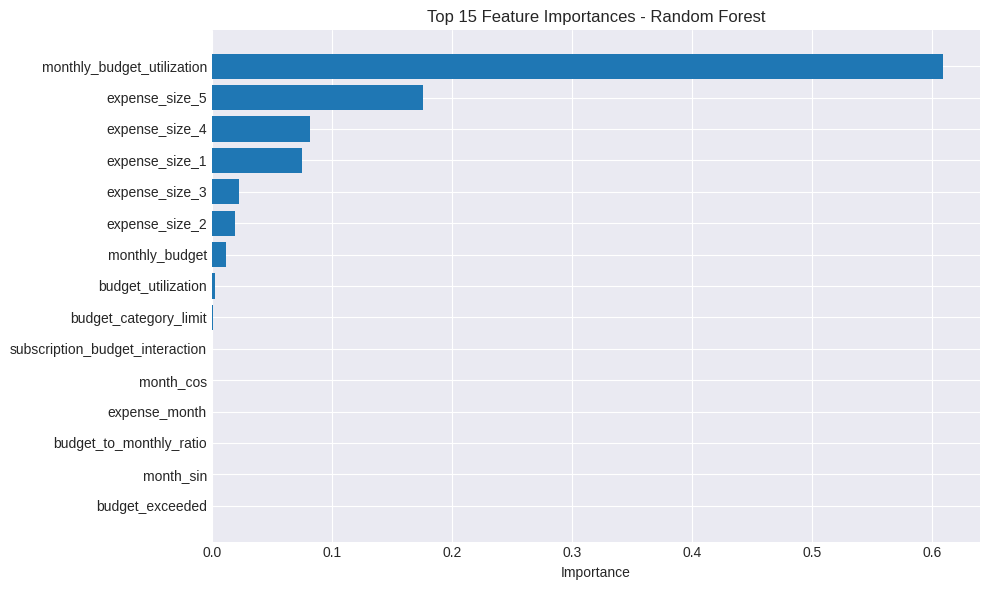

In [39]:
def train_random_forest(X_train, y_train, X_test, y_test, preprocessor):
    """Train and evaluate Random Forest model"""
    print("\n" + "="*60)
    print("RANDOM FOREST REGRESSION MODEL")
    print("="*60)
    
    # Create pipeline with optimized parameters
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # Train model
    import time
    start_time = time.time()
    rf_pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Make predictions
    y_pred_train = rf_pipeline.predict(X_train)
    y_pred_test = rf_pipeline.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²:  {test_r2:.4f}")
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Testing RMSE:  {test_rmse:.2f}")
    print(f"Training MAE: {train_mae:.2f}")
    print(f"Testing MAE:  {test_mae:.2f}")
    print(f"Training Time: {training_time:.2f} seconds")
    
    # Cross-validation score
    cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Feature importance
    feature_names = list(numerical_cols)
    
    # Get one-hot encoded feature names
    preprocessor.fit(X_train)
    if len(categorical_cols) > 0:
        onehot_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
        feature_names.extend(onehot_features)
    
    rf_model = rf_pipeline.named_steps['model']
    
    # Plot feature importance
    if len(feature_names) == len(rf_model.feature_importances_):
        plt.figure(figsize=(10, 6))
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)
        
        plt.barh(feature_importance['feature'], feature_importance['importance'])
        plt.xlabel('Importance')
        plt.title('Top 15 Feature Importances - Random Forest')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
    return {
        'model': rf_pipeline,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'training_time': training_time,
        'cv_scores': cv_scores
    }

# Train Random Forest
rf_results = train_random_forest(X_train, y_train, X_test, y_test, preprocessor)


XGBOOST REGRESSION MODEL
Training R²: 0.9994
Testing R²:  0.9993
Training RMSE: 33.99
Testing RMSE:  37.73
Training MAE: 25.27
Testing MAE:  27.55
Training Time: 1.23 seconds
Cross-validation R²: 0.9993 (+/- 0.0000)


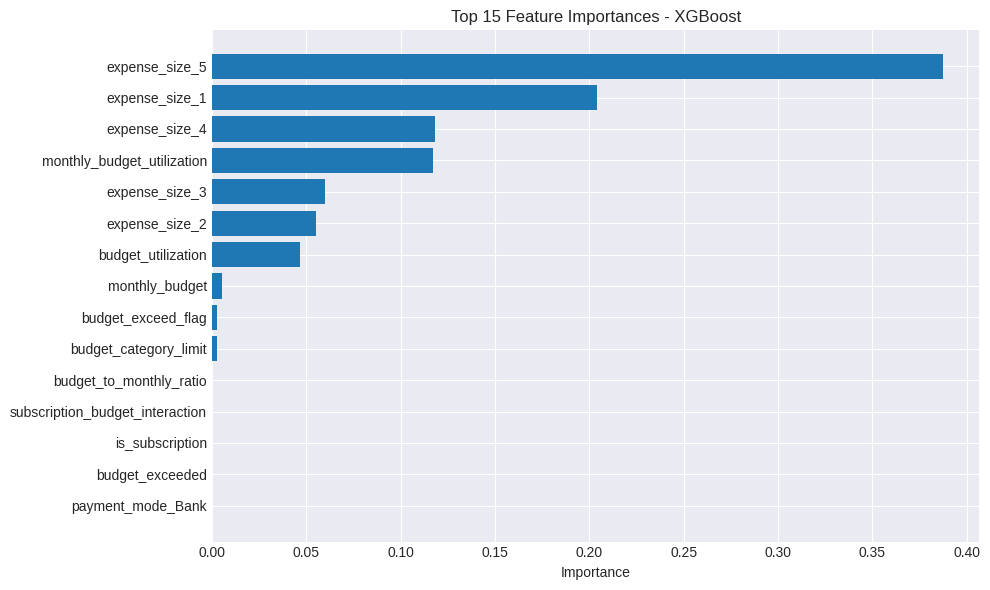

In [40]:
def train_xgboost(X_train, y_train, X_test, y_test, preprocessor):
    """Train and evaluate XGBoost model"""
    print("\n" + "="*60)
    print("XGBOOST REGRESSION MODEL")
    print("="*60)
    
    # Create pipeline with optimized parameters
    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])
    
    # Train model
    import time
    start_time = time.time()
    xgb_pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Make predictions
    y_pred_train = xgb_pipeline.predict(X_train)
    y_pred_test = xgb_pipeline.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²:  {test_r2:.4f}")
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Testing RMSE:  {test_rmse:.2f}")
    print(f"Training MAE: {train_mae:.2f}")
    print(f"Testing MAE:  {test_mae:.2f}")
    print(f"Training Time: {training_time:.2f} seconds")
    
    # Cross-validation score
    cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Feature importance
    xgb_model = xgb_pipeline.named_steps['model']
    
    # Get feature names
    feature_names = list(numerical_cols)
    if len(categorical_cols) > 0:
        preprocessor.fit(X_train)
        onehot_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
        feature_names.extend(onehot_features)
    
    # Plot feature importance
    if len(feature_names) == len(xgb_model.feature_importances_):
        plt.figure(figsize=(10, 6))
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': xgb_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)
        
        plt.barh(feature_importance['feature'], feature_importance['importance'])
        plt.xlabel('Importance')
        plt.title('Top 15 Feature Importances - XGBoost')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
    return {
        'model': xgb_pipeline,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'training_time': training_time,
        'cv_scores': cv_scores
    }

# Train XGBoost
xgb_results = train_xgboost(X_train, y_train, X_test, y_test, preprocessor)


MODEL COMPARISON

Model Performance Comparison:
            Model  Test R²  Train R²  Test RMSE   Test MAE  Training Time (s)  CV R² Mean  CV R² Std
Linear Regression 0.967859  0.967899 259.538548 217.592439           0.284178    0.967866   0.000377
    Random Forest 0.995300  0.995498  99.246728  42.287709          62.357974    0.995521   0.000260
          XGBoost 0.999321  0.999443  37.728233  27.548471           1.234642    0.999309   0.000013


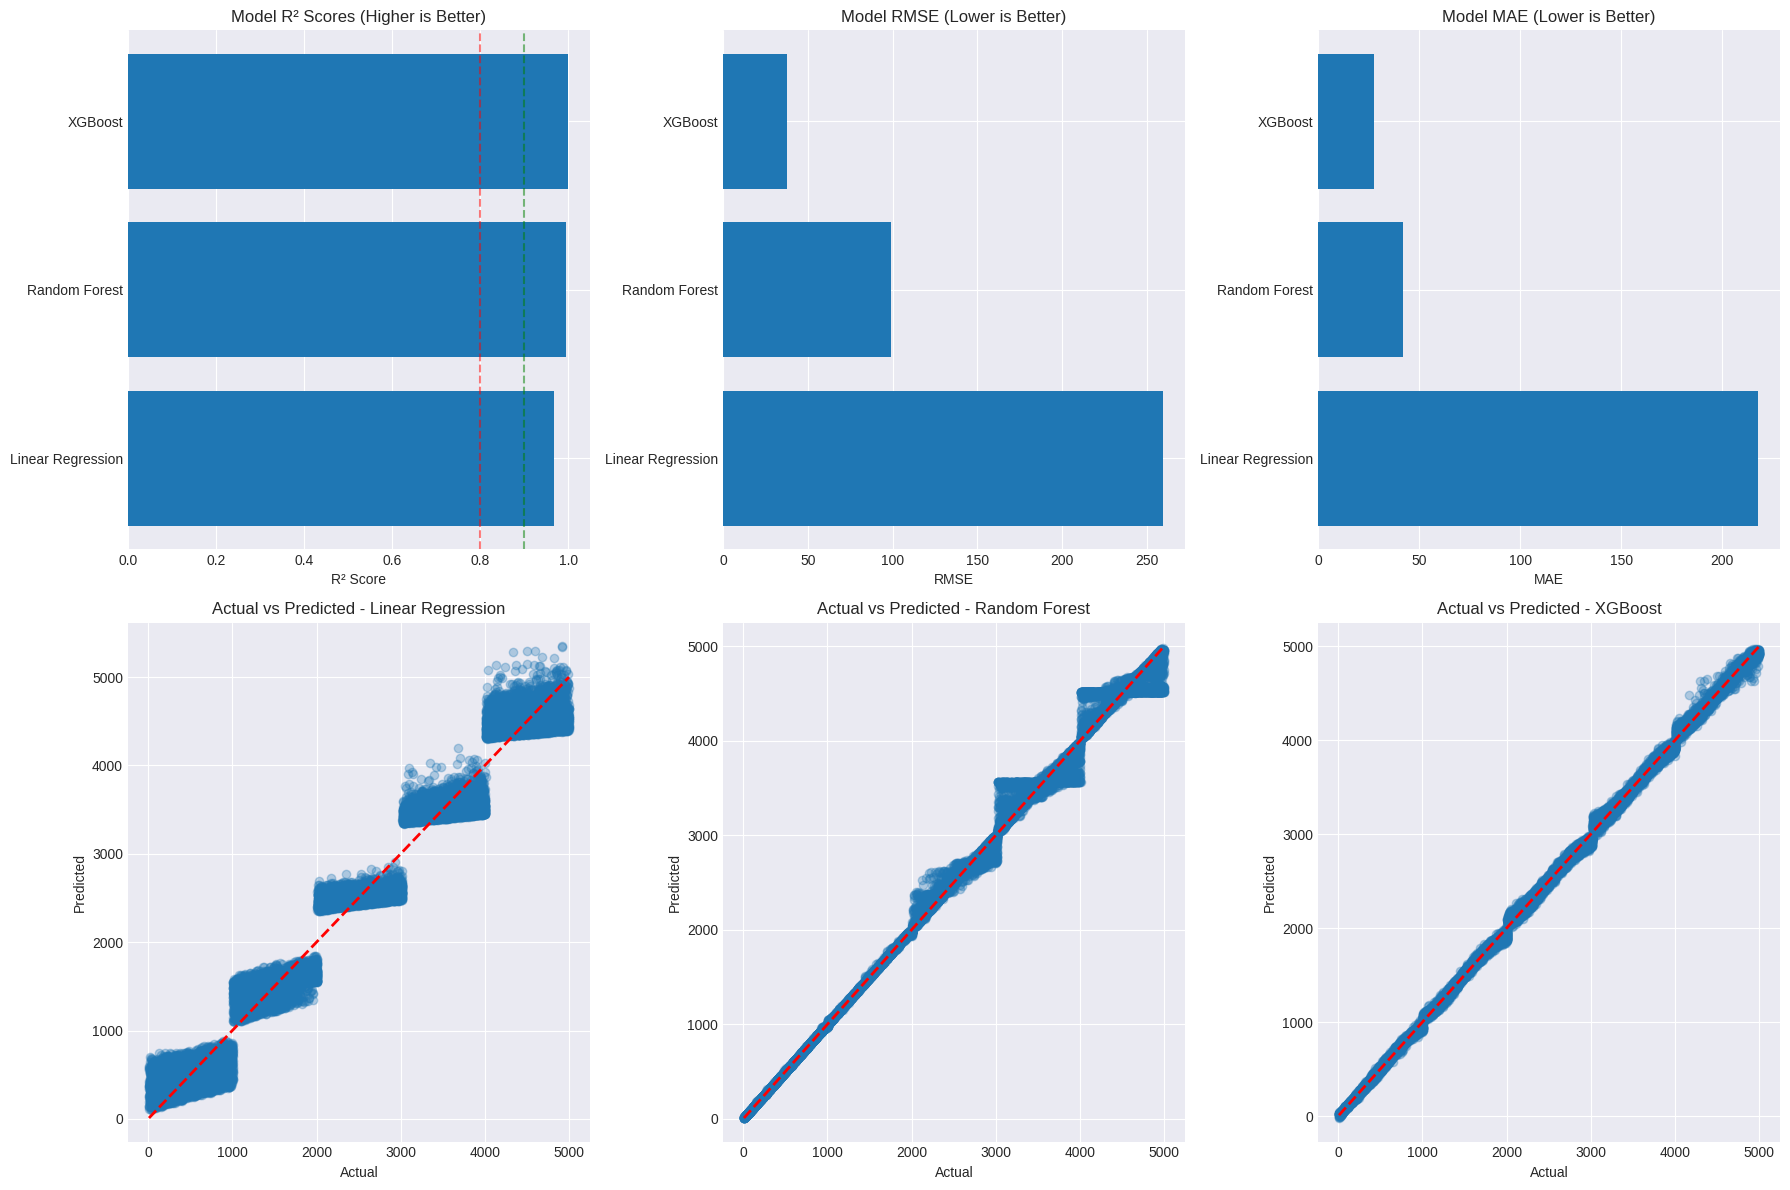

In [41]:
def compare_models(linear_results, rf_results, xgb_results):
    """Compare all three models"""
    print("\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    
    # Create comparison dataframe
    comparison_data = [
        {
            'Model': 'Linear Regression',
            'Test R²': linear_results['test_r2'],
            'Train R²': linear_results['train_r2'],
            'Test RMSE': linear_results['test_rmse'],
            'Test MAE': linear_results['test_mae'],
            'Training Time (s)': linear_results['training_time'],
            'CV R² Mean': linear_results['cv_scores'].mean(),
            'CV R² Std': linear_results['cv_scores'].std()
        },
        {
            'Model': 'Random Forest',
            'Test R²': rf_results['test_r2'],
            'Train R²': rf_results['train_r2'],
            'Test RMSE': rf_results['test_rmse'],
            'Test MAE': rf_results['test_mae'],
            'Training Time (s)': rf_results['training_time'],
            'CV R² Mean': rf_results['cv_scores'].mean(),
            'CV R² Std': rf_results['cv_scores'].std()
        },
        {
            'Model': 'XGBoost',
            'Test R²': xgb_results['test_r2'],
            'Train R²': xgb_results['train_r2'],
            'Test RMSE': xgb_results['test_rmse'],
            'Test MAE': xgb_results['test_mae'],
            'Training Time (s)': xgb_results['training_time'],
            'CV R² Mean': xgb_results['cv_scores'].mean(),
            'CV R² Std': xgb_results['cv_scores'].std()
        }
    ]
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\nModel Performance Comparison:")
    print(comparison_df.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # R² Comparison
    axes[0, 0].barh(comparison_df['Model'], comparison_df['Test R²'])
    axes[0, 0].set_xlabel('R² Score')
    axes[0, 0].set_title('Model R² Scores (Higher is Better)')
    axes[0, 0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5)
    axes[0, 0].axvline(x=0.9, color='green', linestyle='--', alpha=0.5)
    
    # RMSE Comparison
    axes[0, 1].barh(comparison_df['Model'], comparison_df['Test RMSE'])
    axes[0, 1].set_xlabel('RMSE')
    axes[0, 1].set_title('Model RMSE (Lower is Better)')
    
    # MAE Comparison
    axes[0, 2].barh(comparison_df['Model'], comparison_df['Test MAE'])
    axes[0, 2].set_xlabel('MAE')
    axes[0, 2].set_title('Model MAE (Lower is Better)')
    
    # Actual vs Predicted for each model
    models = {
        'Linear Regression': linear_results['model'],
        'Random Forest': rf_results['model'],
        'XGBoost': xgb_results['model']
    }
    
    for idx, (model_name, model) in enumerate(models.items()):
        y_pred = model.predict(X_test)
        
        axes[1, idx].scatter(y_test, y_pred, alpha=0.3)
        axes[1, idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[1, idx].set_xlabel('Actual')
        axes[1, idx].set_ylabel('Predicted')
        axes[1, idx].set_title(f'Actual vs Predicted - {model_name}')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

# Compare models
comparison_df = compare_models(linear_results, rf_results, xgb_results)

In [42]:
def save_models_and_results(comparison_df, linear_results, rf_results, xgb_results, preprocessor, numerical_cols, categorical_cols):
    """Save all models and results"""
    print("\n" + "="*60)
    print("SAVING MODELS AND RESULTS")
    print("="*60)
    
    # Determine best model based on Test R²
    best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
    print(f"Best model: {best_model_name}")
    
    # Map model names to results
    model_map = {
        'Linear Regression': linear_results['model'],
        'Random Forest': rf_results['model'],
        'XGBoost': xgb_results['model']
    }
    
    best_model = model_map[best_model_name]
    
    # Create safe filename
    safe_name = best_model_name.replace(' ', '_').lower()
    
    # Save the best model
    model_filename = f'best_expense_model_{safe_name}.pkl'
    joblib.dump(best_model, model_filename)
    print(f"✓ Best model ({best_model_name}) saved as: {model_filename}")
    
    # Save preprocessor
    preprocessor_filename = 'expense_preprocessor.pkl'
    joblib.dump(preprocessor, preprocessor_filename)
    print(f"✓ Preprocessor saved as: {preprocessor_filename}")
    
    # Save all models
    for model_name, model in model_map.items():
        safe_name = model_name.replace(' ', '_').lower()
        joblib.dump(model, f'{safe_name}_model.pkl')
        print(f"✓ {model_name} model saved")
    
    # Save feature information
    feature_info = {
        'numerical_features': numerical_cols,
        'categorical_features': categorical_cols,
        'all_features': list(X_train.columns),
        'target': 'amount'
    }
    
    with open('feature_info.pkl', 'wb') as f:
        pickle.dump(feature_info, f)
    print(f"✓ Feature information saved")
    
    # Save performance metrics
    performance_metrics = comparison_df.to_dict('records')
    with open('performance_metrics.json', 'w') as f:
        json.dump(performance_metrics, f, indent=4)
    print(f"✓ Performance metrics saved")
    
    # Save comparison dataframe as CSV
    comparison_df.to_csv('model_comparison_results.csv', index=False)
    print(f"✓ Comparison results saved as CSV")
    
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)
    print(f"Best Model: {best_model_name}")
    print(f"Test R²: {comparison_df['Test R²'].max():.4f}")
    print(f"Test RMSE: {comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Test RMSE']:.2f}")
    print(f"Models trained: {len(comparison_df)}")
    print("="*60)

# Save everything
save_models_and_results(comparison_df, linear_results, rf_results, xgb_results, 
                        preprocessor, numerical_cols, categorical_cols)


SAVING MODELS AND RESULTS
Best model: XGBoost
✓ Best model (XGBoost) saved as: best_expense_model_xgboost.pkl
✓ Preprocessor saved as: expense_preprocessor.pkl
✓ Linear Regression model saved
✓ Random Forest model saved
✓ XGBoost model saved
✓ Feature information saved
✓ Performance metrics saved
✓ Comparison results saved as CSV

FINAL SUMMARY
Best Model: XGBoost
Test R²: 0.9993
Test RMSE: 37.73
Models trained: 3


In [47]:
def test_saved_models():
    """Test the saved models with sample predictions"""
    print("\n" + "="*60)
    print("TESTING SAVED MODELS")
    print("="*60)
    
    # Load the best model
    best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
    safe_name = best_model_name.replace(' ', '_').lower()
    model_filename = f'best_expense_model_{safe_name}.pkl'
    
    loaded_model = joblib.load(model_filename)
    
    # Make sample predictions
    print(f"\nTesting {best_model_name} with 5 samples:")
    print("-" * 40)
    
    for i in range(5):
        sample_input = X_test.iloc[[i]]
        actual_value = y_test.iloc[i]
        predicted_value = loaded_model.predict(sample_input)[0]
        
        error = abs(predicted_value - actual_value)
        percentage_error = (error / actual_value * 100) if actual_value != 0 else 0
        
        print(f"\nSample {i+1}:")
        print(f"  Actual Amount: ₹{actual_value:.2f}")
        print(f"  Predicted Amount: ₹{predicted_value:.2f}")
        print(f"  Error: ₹{error:.2f}")
        print(f"  Percentage Error: {percentage_error:.2f}%")
    
    # Test all models
    print(f"\n\nTesting all models with first sample:")
    print("-" * 40)
    
    sample_input = X_test.iloc[[0]]
    actual_value = y_test.iloc[0]
    
    for model_name in ['linear_regression', 'random_forest', 'xgboost']:
        model = joblib.load(f'{model_name}_model.pkl')
        predicted_value = model.predict(sample_input)[0]
        error = abs(predicted_value - actual_value)
        
        print(f"\n{model_name.replace('_', ' ').title()}:")
        print(f"  Predicted: ₹{predicted_value:.2f}")
        print(f"  Error: ₹{error:.2f}")

# Test saved models
test_saved_models()


TESTING SAVED MODELS

Testing XGBoost with 5 samples:
----------------------------------------

Sample 1:
  Actual Amount: ₹3371.96
  Predicted Amount: ₹3303.04
  Error: ₹68.92
  Percentage Error: 2.04%

Sample 2:
  Actual Amount: ₹4391.36
  Predicted Amount: ₹4423.72
  Error: ₹32.37
  Percentage Error: 0.74%

Sample 3:
  Actual Amount: ₹3255.50
  Predicted Amount: ₹3292.62
  Error: ₹37.12
  Percentage Error: 1.14%

Sample 4:
  Actual Amount: ₹3010.93
  Predicted Amount: ₹2872.29
  Error: ₹138.64
  Percentage Error: 4.60%

Sample 5:
  Actual Amount: ₹2219.50
  Predicted Amount: ₹2181.72
  Error: ₹37.79
  Percentage Error: 1.70%


Testing all models with first sample:
----------------------------------------

Linear Regression:
  Predicted: ₹3521.87
  Error: ₹149.91

Random Forest:
  Predicted: ₹3359.38
  Error: ₹12.58

Xgboost:
  Predicted: ₹3303.04
  Error: ₹68.92


In [53]:
import pandas as pd
import joblib

# Input data with missing columns added
my_data = {
    'category': 'Transportation',
    'expense_month': 7,
    'payment_mode': 'Cash',
    'is_subscription': 0,
    'budget_category_limit': 3000.0,
    'monthly_budget': 25000.0,
    'budget_exceeded': 0,
    'group_expense': 0,
    'savings_goal_linked': 0,
    'alert_triggered': 0,
    'month_cos': 0.5,  # Example value, compute based on actual data
    'month_sin': 0.5,  # Example value, compute based on actual data
    'is_year_end': 0,  # Example value, set based on actual data
    'budget_exceed_flag': 0,  # Example value
    'quarter': 3,  # Example value, based on the month (July is Q3)
    'budget_utilization': 0.2,  # Example value, compute based on actual data
    'budget_to_monthly_ratio': 0.12,  # Example value, compute based on actual data
    'savings_alert_interaction': 0,  # Example value
    'is_quarter_end': 0,  # Example value, set based on the month
    'subscription_budget_interaction': 0,  # Example value
    'monthly_budget_utilization': 0.1,  # Example value, compute based on actual data
    'expense_size': 1,  # Example value, set based on actual data
    'group_alert_interaction': 0  # Example value
}

# Convert to DataFrame
data_df = pd.DataFrame([my_data])

# Load the pre-trained model
rf_model = joblib.load('/kaggle/working/random_forest_model.pkl')

# Predict using the model
prediction = rf_model.predict(data_df)[0]

# Output the prediction
print(f"Predicted expense: ₹{prediction:.2f}")


Predicted expense: ₹490.67
